# RBOB MM Lead/Lag — Using Legacy COT Data (BBG-sourced)

Same lead/lag analysis as the disaggregated notebook, but using the
COT data from our existing repo pipeline (BBG-sourced, in `cache/`).

Goal: confirm that the price → MM trend-following finding is consistent
across data sources.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT from repo + prices

In [2]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)

# COT panel (weekly, Tuesdays, with release_date)
cot = pdr.read_cot(FutureTicker.RBOB)
cot['tradeDate'] = pd.to_datetime(cot['tradeDate'])
cot['release_date'] = pd.to_datetime(cot['release_date'])

print(f'COT rows: {len(cot)}')
print(f'Range: {cot["tradeDate"].min().date()} -> {cot["tradeDate"].max().date()}')
print(f'Columns: Commercial + ManagedMoney (legacy categories)')

COT rows: 809
Range: 2010-01-05 -> 2025-07-01
Columns: Commercial + ManagedMoney (legacy categories)


In [3]:
# Daily prices
prices = pdr.read_prices(FutureTicker.RBOB)
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices = prices[['tradeDate', 'F1_RolledPrice']].sort_values('tradeDate')

print(f'Price rows: {len(prices)}')
print(f'Range: {prices["tradeDate"].min().date()} -> {prices["tradeDate"].max().date()}')

Price rows: 3900
Range: 2010-01-04 -> 2025-07-07


## 2. Join on release date

In [4]:
df = pd.merge_asof(
    cot.sort_values('release_date'),
    prices.rename(columns={'tradeDate': 'release_date'}),
    on='release_date', direction='backward', tolerance=pd.Timedelta(days=3),
)

df.dropna(subset=['ManagedMoney_NetPosition', 'F1_RolledPrice'], inplace=True)
df.sort_values('tradeDate', inplace=True)
df.reset_index(drop=True, inplace=True)

# Weekly changes
df['mm_net_chg'] = df['ManagedMoney_NetPosition'].diff()
df['mm_long_chg'] = df['ManagedMoney_LongPosition'].diff()
df['mm_short_chg'] = df['ManagedMoney_ShortPosition'].diff()
df['price_ret'] = df['F1_RolledPrice'].pct_change() * 100

df.dropna(subset=['mm_net_chg', 'price_ret'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean rows: {len(df)}')
print(f'Range: {df["tradeDate"].min().date()} -> {df["tradeDate"].max().date()}')

Clean rows: 808
Range: 2010-01-12 -> 2025-07-01


## 3. Contemporaneous correlation

In [5]:
for label, col in [('MM Net change', 'mm_net_chg'),
                    ('MM Long change', 'mm_long_chg'),
                    ('MM Short change', 'mm_short_chg')]:
    rho, p = sp_stats.spearmanr(df[col], df['price_ret'])
    print(f'  {label:20s} vs price return:  rho = {rho:+.3f}  (p = {p:.1e})')

  MM Net change        vs price return:  rho = +0.006  (p = 8.7e-01)
  MM Long change       vs price return:  rho = +0.003  (p = 9.4e-01)
  MM Short change      vs price return:  rho = +0.002  (p = 9.5e-01)


## 4. Cross-correlation function

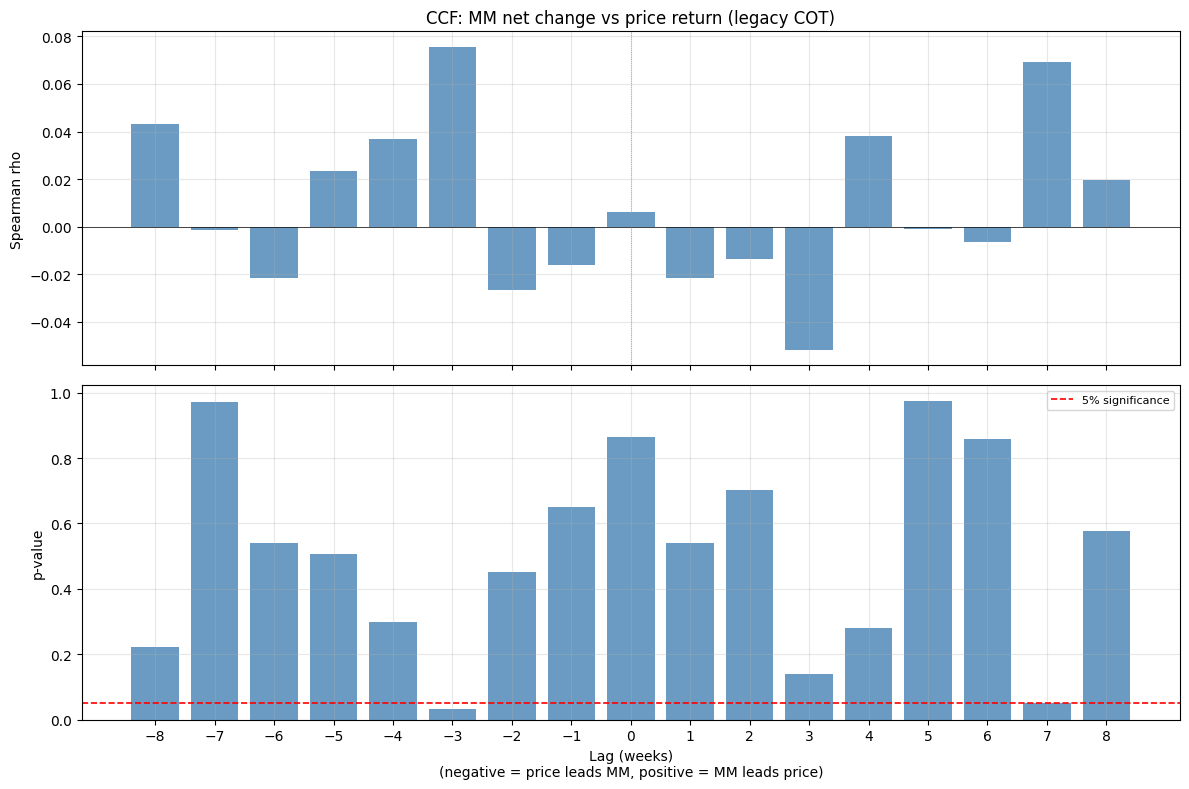

 Lag       rho       p-val  Interpretation
-------------------------------------------------------
  -8   +0.043       2.2e-01  price leads MM by 8w
  -7   -0.001       9.7e-01  price leads MM by 7w
  -6   -0.022       5.4e-01  price leads MM by 6w
  -5   +0.023       5.1e-01  price leads MM by 5w
  -4   +0.037       3.0e-01  price leads MM by 4w
  -3   +0.076 *     3.2e-02  price leads MM by 3w
  -2   -0.027       4.5e-01  price leads MM by 2w
  -1   -0.016       6.5e-01  price leads MM by 1w
   0   +0.006       8.7e-01  same week
   1   -0.022       5.4e-01  MM leads price by 1w
   2   -0.013       7.0e-01  MM leads price by 2w
   3   -0.052       1.4e-01  MM leads price by 3w
   4   +0.038       2.8e-01  MM leads price by 4w
   5   -0.001       9.7e-01  MM leads price by 5w
   6   -0.006       8.6e-01  MM leads price by 6w
   7   +0.069       5.0e-02  MM leads price by 7w
   8   +0.020       5.8e-01  MM leads price by 8w


In [6]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

net_vals = df['mm_net_chg'].values
price_vals = df['price_ret'].values

lags, rhos, pvals = compute_ccf(net_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags, rhos, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: RBOB MM net change vs price return (legacy COT)')

ax = axes[1]
ax.bar(lags, pvals, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n'
              '(negative = price leads MM, positive = MM leads price)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}  Interpretation')
print('-' * 55)
for k, r, p in zip(lags, rhos, pvals):
    sig = '*' if p < 0.05 else ' '
    if k < 0:
        interp = f'price leads MM by {-k}w'
    elif k == 0:
        interp = 'same week'
    else:
        interp = f'MM leads price by {k}w'
    print(f'{k:>4d}  {r:>+7.3f} {sig}  {p:>10.1e}  {interp}')

## 5. Comparison with disaggregated report

Side by side: legacy COT (our data) vs CFTC disaggregated.

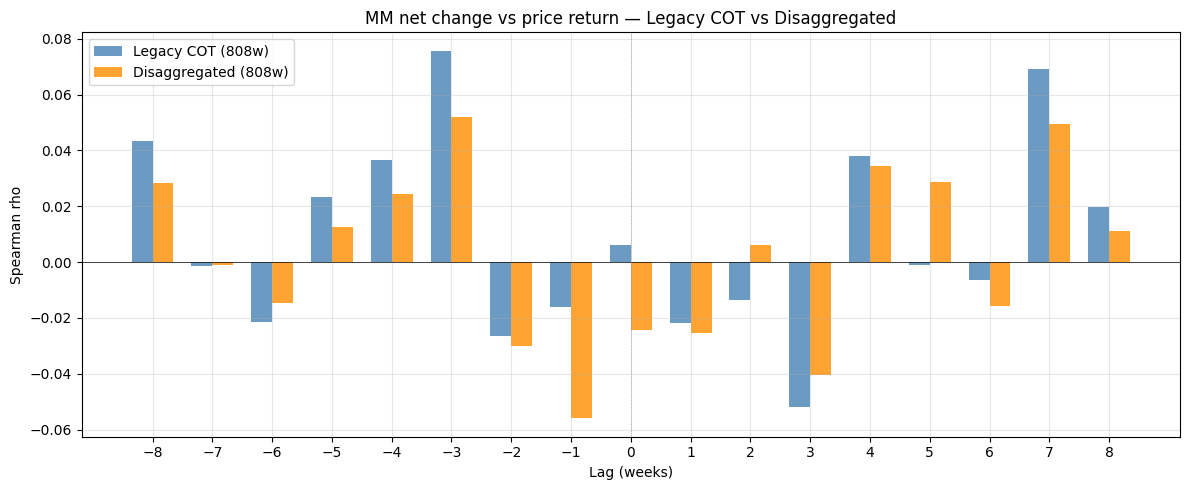

 Lag    Legacy    Disagg      Diff
-----------------------------------
  -8    +0.043    +0.028    +0.015
  -7    -0.001    -0.001    -0.000
  -6    -0.022    -0.015    -0.007
  -5    +0.023    +0.012    +0.011
  -4    +0.037    +0.025    +0.012
  -3    +0.076    +0.052    +0.024
  -2    -0.027    -0.030    +0.004
  -1    -0.016    -0.056    +0.040
   0    +0.006    -0.024    +0.030
   1    -0.022    -0.025    +0.004
   2    -0.013    +0.006    -0.020
   3    -0.052    -0.040    -0.011
   4    +0.038    +0.034    +0.004
   5    -0.001    +0.029    -0.030
   6    -0.006    -0.016    +0.009
   7    +0.069    +0.049    +0.020
   8    +0.020    +0.011    +0.009


In [7]:
# Load disaggregated for comparison
CFTC_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'
raw_cftc = pd.read_csv(CFTC_PATH, low_memory=False)
wti_cftc = raw_cftc[raw_cftc['contract_market_name'] == 'GASOLINE RBOB'].copy()
wti_cftc['as_of_date'] = pd.to_datetime(wti_cftc['report_date_as_yyyy_mm_dd'])
days_ahead = (4 - wti_cftc['as_of_date'].dt.dayofweek) % 7
wti_cftc['release_date'] = wti_cftc['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti_cftc['mm_net'] = (pd.to_numeric(wti_cftc['m_money_positions_long_all'], errors='coerce')
                     - pd.to_numeric(wti_cftc['m_money_positions_short_all'], errors='coerce'))
wti_cftc.sort_values('as_of_date', inplace=True)

df_cftc = pd.merge_asof(
    wti_cftc[['as_of_date', 'release_date', 'mm_net']].sort_values('release_date'),
    prices.rename(columns={'tradeDate': 'release_date'}),
    on='release_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
df_cftc.dropna(inplace=True)
df_cftc.sort_values('as_of_date', inplace=True)
df_cftc['mm_net_chg'] = df_cftc['mm_net'].diff()
df_cftc['price_ret'] = df_cftc['F1_RolledPrice'].pct_change() * 100
df_cftc.dropna(inplace=True)

lags_c, rhos_c, _ = compute_ccf(df_cftc['mm_net_chg'].values,
                                  df_cftc['price_ret'].values, MAX_LAG)

# Plot side by side
fig, ax = plt.subplots(figsize=(12, 5))
w = 0.35
x = np.array(lags)
ax.bar(x - w/2, rhos, w, color='steelblue', alpha=0.8, label=f'Legacy COT ({len(df)}w)')
ax.bar(x + w/2, rhos_c, w, color='darkorange', alpha=0.8, label=f'Disaggregated ({len(df_cftc)}w)')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Spearman rho')
ax.set_title('RBOB MM net change vs price return — Legacy COT vs Disaggregated')
ax.set_xticks(lags)
ax.legend()
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"Legacy":>8s}  {"Disagg":>8s}  {"Diff":>8s}')
print('-' * 35)
for k, rl, rc in zip(lags, rhos, rhos_c):
    print(f'{k:>4d}  {rl:>+8.3f}  {rc:>+8.3f}  {rl-rc:>+8.3f}')

## 6. 2-year blocks (legacy COT)

In [8]:
df['year'] = df['tradeDate'].dt.year

blocks_2y = [
    ('2010-2011', (2010, 2011)),
    ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)),
    ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)),
    ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)),
    ('2024-2025', (2024, 2025)),
]

KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    net_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                net_b[:len(net_b)-k] if k > 0 else net_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(net_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011   103  -0.195  -0.537  +0.019  +0.146  +0.143
   2012-2013   105  +0.181  +0.282  -0.019  -0.090  -0.112
   2014-2015   104  +0.039  +0.003  -0.005  +0.002  +0.037
   2016-2017   104  -0.148  -0.425  -0.131  +0.135  +0.089
   2018-2019   105  +0.021  -0.006  +0.180  +0.023  +0.034
   2020-2021   104  -0.075  +0.120  -0.177  -0.267  -0.079
   2022-2023   104  -0.076  +0.107  +0.010  +0.029  -0.161
   2024-2025    79  +0.020  +0.453  -0.049  -0.116  +0.054
 Full sample   808  -0.027  -0.016  +0.006  -0.022  -0.013
